## Import Required Libraries

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

## Dataset Overview

In [97]:
data=pd.read_csv(r"C:\Users\karan\OneDrive\Desktop\Projects\Fifa20\PRCP-1004-Fifa20\Data\players_20.csv")

In [98]:
data.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [99]:
data.shape

(18278, 104)

Insight:

- 18,278 rows → Individual data records (observations / samples)
- 104 columns → Features or variables describing each record

In [100]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), object(43)
memory usage: 14.5+ MB


In [101]:
data.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


# Feature Engineering

- Converting Positional Ratings to Numeric Format

In [102]:

position_cols = [
    'ls','st','rs','lw','lf','cf','rf','rw',
    'lam','cam','ram','lm','cm','rm',
    'lwb','ldm','cdm','rdm','rwb',
    'lb','lcb','cb','rcb','rb'
]

for col in position_cols:
    data[col] = (
        data[col]
        .astype(str)
        .str.split('+')
        .str[0]
        .replace('nan', np.nan)
        .astype(float)
    )

| Feature Type              | Action Taken                    |
| ------------------------- | ------------------------------- |
| Positional Ratings (68+2) | Converted to base numeric value |
| String → Numeric          | Ensured numeric consistency     |
| Temporary boosts          | Ignored for modeling            |
| Data type conversion      | Converted to float              |


# Missing Value Handling

In [103]:
missing = data.isnull().sum()
missing

sofifa_id        0
player_url       0
short_name       0
long_name        0
age              0
              ... 
lb            2036
lcb           2036
cb            2036
rcb           2036
rb            2036
Length: 104, dtype: int64

#### Check Missing Values

In [104]:
missing_features = missing[missing > 0].sort_values(ascending=False)
missing_features.head()

loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_diving               16242
dtype: int64

#### Check Missing Values in Percentage

In [105]:
missing_percent = (missing_features / len(data)) * 100
missing_percent.head(11)

loaned_from             94.266331
nation_position         93.839589
nation_jersey_number    93.839589
player_tags             91.798884
gk_diving               88.860926
gk_reflexes             88.860926
gk_kicking              88.860926
gk_handling             88.860926
gk_speed                88.860926
gk_positioning          88.860926
player_traits           58.605974
dtype: float64

### Drop Identity, URLs & Metadata

- These are identifiers
- Do not describe player ability
- Increase noise, no analytical value

In [106]:
drop_identity_cols = [
    'sofifa_id','player_url','short_name','long_name','dob',
    'nation_flag_url','club_logo_url','club_flag_url','player_face_url'
]

data.drop(columns=drop_identity_cols, inplace=True, errors='ignore')

- sofifa_id
- player_url
- short_name
- long_name
- dob
- nation_flag_url
- club_logo_url
- club_flag_url
- player_face_url

### Drop Text-Heavy & Unstructured Columns

- Free text
- Requires NLP (out of scope)
- High missing values
- Not essential for skill-based clustering

In [107]:
drop_text_cols = ['player_traits','player_tags']
data.drop(columns=drop_text_cols, inplace=True, errors='ignore')

- player_traits
- player_tags

### Drop Goalkeeper-Only Features

**Dataset contains mostly outfield players.** <br>

**GK attributes :**

- Are not applicable
- Have >85% missing values
- Distort distance-based clustering

In [108]:
drop_gk_cols = [
    'gk_diving','gk_reflexes','gk_kicking',
    'gk_handling','gk_speed','gk_positioning'
]

data.drop(columns=drop_gk_cols, inplace=True, errors='ignore')

- gk_diving
- gk_reflexes
- gk_kicking
- gk_handling
- gk_speed
- gk_positioning

### Drop Contract / National Team Context Columns

In [109]:
drop_context_cols = [
    'loaned_from','nation_position','nation_jersey_number'
]

data.drop(columns=drop_context_cols, inplace=True, errors='ignore')

- loaned_from
- nation_position
- nation_jersey_number

### Features Not Used in Modeling (Overall & Position)


| **Feature**  | **Why Not Used in Modeling**                                                                     |
| ------------ | --------------------------------------------------------------------------------------------------------------------- |
| **Overall**  | Pre-aggregated rating that dominates clustering and biases results toward player quality instead of skill composition |
| **Position** | Predefined label; using it would force clusters instead of discovering natural skill-based groups                     |

These features were excluded from the clustering model to avoid bias and ensure that players are grouped based on their complete skill attributes rather than predefined ratings or positions.

#### Recheck Dataset Shape

In [110]:
data.shape

(18278, 88)

- 18,278 rows → 18,278 football players
- 88 columns → 88 remaining features after dropping irrelevant ones

#### Recheck Missing Values

In [111]:
data.isnull().sum()[data.isnull().sum() > 0].sort_values(ascending=False).head() #Show Missing Values in Numbers

defending    2036
dribbling    2036
passing      2036
shooting     2036
pace         2036
dtype: int64

#### Recheck Missing Values in Percentage

In [112]:
(data.isnull().mean() * 100)[lambda x: x > 0].sort_values(ascending=False).head() # Show Missing Values in Percentage

defending    11.139074
dribbling    11.139074
passing      11.139074
shooting     11.139074
pace         11.139074
dtype: float64

### Handle Remaining Missing Values

- Apply domain-aware imputation.

#### Skill & Position Ratings → 0

In [113]:
skill_position_cols = [
    'pace','shooting','passing','dribbling','defending','physic',
    'ls','st','rs','lw','lf','cf','rf','rw',
    'lam','cam','ram','lm','cm','rm',
    'lwb','ldm','cdm','rdm','rwb',
    'lb','lcb','cb','rcb','rb'
]

data[skill_position_cols] = data[skill_position_cols].fillna(0)


#### Other Numerical → Median

In [114]:
num_cols = data.select_dtypes(include='number').columns
data[num_cols] = data[num_cols].fillna(data[num_cols].median())

#### Categorical → Mode

In [115]:
cat_cols = data.select_dtypes(include='object').columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

| Feature Type         | Method Used   | Reason                      |
| -------------------- | ------------- | --------------------------- |
| Positional skills    | Filled with 0 | Not applicable              |
| Numerical features   | Median        | Robust to outliers          |
| Categorical features | Mode          | Preserves most common value |


### Check Total Missing Values in Dataset

In [116]:
data.isnull().sum().sum()

np.int64(0)

**Conclusion :** 
- The dataset was successfully explored, cleaned, and prepared. 
- All irrelevant and high-missing features were removed, positional ratings were converted into numeric format, and missing values were handled using domain-aware strategies. 
- The final dataset is clean, consistent, and ready for clustering analysis.

# Dataset Overview

| Item                            | Description                           |  
| ------------------------------- | ------------------------------------- |
| Dataset Type                    | Professional football players dataset |
| Total Records                   | 18,278 players                        |  
| Total Features (initial)        | 100+                                  |
| Total Features (after cleaning) | 88                                    |
| Data Types                      | Numerical & Categorical               |
| Unit of Analysis                | One row = One football player         |


# Feature Categories

| Category            | Examples                | Purpose              |
| ------------------- | ----------------------- | -------------------- |
| Player Info         | Age, Height, Weight     | Physical profile     |
| Skill Attributes    | Pace, Shooting, Passing | Performance analysis |
| Positional Ratings  | ST, CM, LW, CB          | Role adaptability    |
| Mental Attributes   | Composure, Vision       | Decision making      |
| Physical Attributes | Stamina, Strength       | Endurance & power    |
| Market Info         | Wage, Value             | Business context     |


# Exploratory Data Analysis (EDA)

## Univariate Analysis

- Univariate Analysis is the analysis of a single variable at a time to understand its distribution, central tendency, spread, and pattern.

### Age Distribution

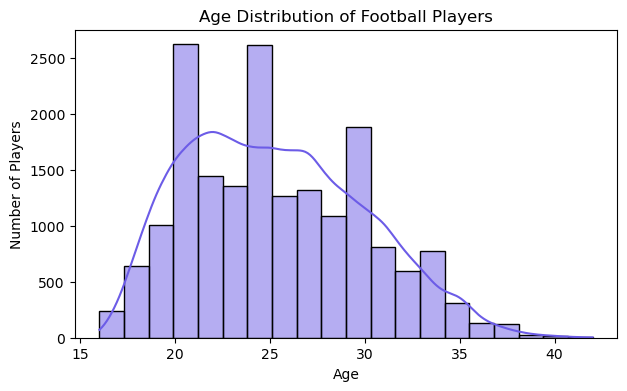

In [117]:
plt.figure(figsize=(7,4))
sns.histplot(data['age'], bins=20, kde=True, color='#6c5ce7')
plt.title("Age Distribution of Football Players")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

### Age Distribution and Outlier Analysis


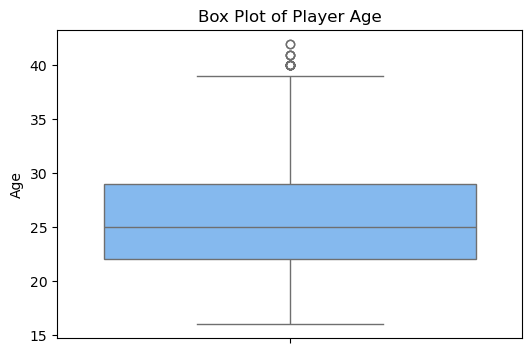

In [118]:
plt.figure(figsize=(6,4))
sns.boxplot(y=data['age'], color='#74b9ff')
plt.title("Box Plot of Player Age")
plt.ylabel("Age")
plt.show()

**Insight :**

- Age box plot are valid outliers, not errors.

| **Aspect**            | **Observation** | **Interpretation / Insight**                                      |
| --------------------- | --------------- | ----------------------------------------------------------------- |
| Age Range             | ~16 to 42 years | Dataset includes young, prime, and senior players                 |
| Peak Age Group        | 22–26 years     | Represents the **prime performance age** in professional football |
| Majority of Players   | 20–30 years     | Most players compete at elite level during early to mid-career    |
| Younger Players (<20) | Very few        | Entry into professional football is limited at very young ages    |
| Older Players (>30)   | Gradual decline | Physical performance starts decreasing after 30                   |
| Players >35           | Very rare       | Indicates retirement or reduced participation                     |
| Distribution Shape    | Right-skewed    | Fewer older players compared to younger players                   |


### Overall Rating Distribution

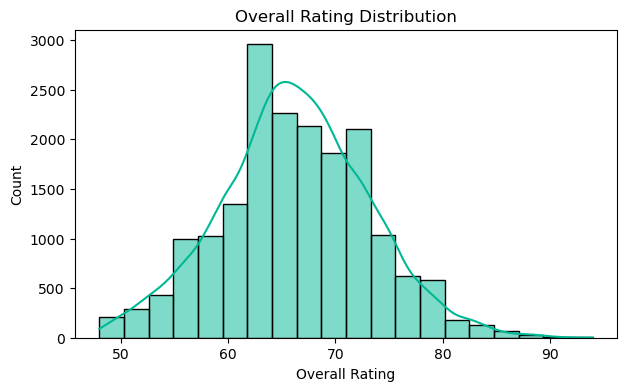

In [119]:
plt.figure(figsize=(7,4))
sns.histplot(data['overall'], bins=20, kde=True, color='#00b894')
plt.title("Overall Rating Distribution")
plt.xlabel("Overall Rating")
plt.ylabel("Count")
plt.show()


| **Aspect**               | **Observation** | **Interpretation / Insight**                                          |
| ------------------------ | --------------- | --------------------------------------------------------------------- |
| Rating Range             | ~48 to 93       | Dataset includes low-rated to elite players                           |
| Peak Rating Range        | 60–70           | Majority of players fall in the **average to above-average** category |
| Most Common Ratings      | Around 63–66    | Represents standard professional football level                       |
| High-Rated Players (>80) | Very few        | Elite players are rare                                                |
| Low-Rated Players (<55)  | Few             | Minimum professional threshold                                        |
| Distribution Shape       | Right-skewed    | Fewer players at very high ratings                                    |
| Variability              | Moderate spread | Skills vary but cluster around mid-range                              |


## Bivariate Analysis

Bivariate analysis studies the relationship between two variables to understand how one variable affects another.

### Overall Rating by Preferred Foot

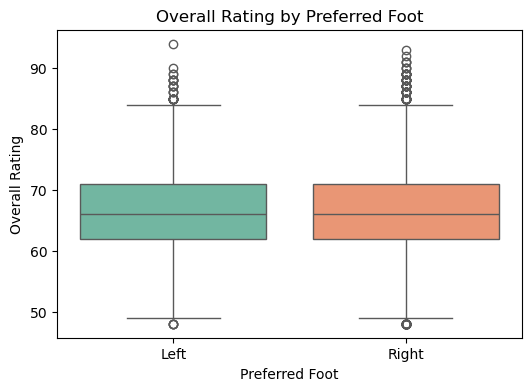

In [120]:
plt.figure(figsize=(6,4))
sns.boxplot(
    x='preferred_foot',
    y='overall',
    hue='preferred_foot',
    data=data,
    palette='Set2',
    legend=False
)
plt.title("Overall Rating by Preferred Foot")
plt.xlabel("Preferred Foot")
plt.ylabel("Overall Rating")
plt.show()

| **Aspect**                   | **Left-Footed Players** | **Right-Footed Players** | **Insight / Conclusion**                               |
| ---------------------------- | ----------------------- | ------------------------ | ------------------------------------------------------ |
| Median Overall Rating        | ~65–66                  | ~66                      | Median ratings are almost identical                    |
| Rating Spread (IQR)          | ~62 to 71               | ~62 to 71                | Both groups show similar variability                   |
| Minimum Rating               | ~48–49                  | ~48–49                   | Comparable lower performance bound                     |
| Maximum Rating (Non-outlier) | ~84                     | ~84                      | Upper performance range is similar                     |
| High-Rating Outliers         | Present (85–94)         | Present (85–94)          | Elite players exist in both groups                     |
| Overall Distribution         | Balanced                | Balanced                 | Preferred foot does not strongly impact overall rating |

- High-rating outliers were retained in the dataset, as they represent elite professional players rather than data errors. These values are meaningful for performance analysis and business insights.


### Overall Rating by Work Rate

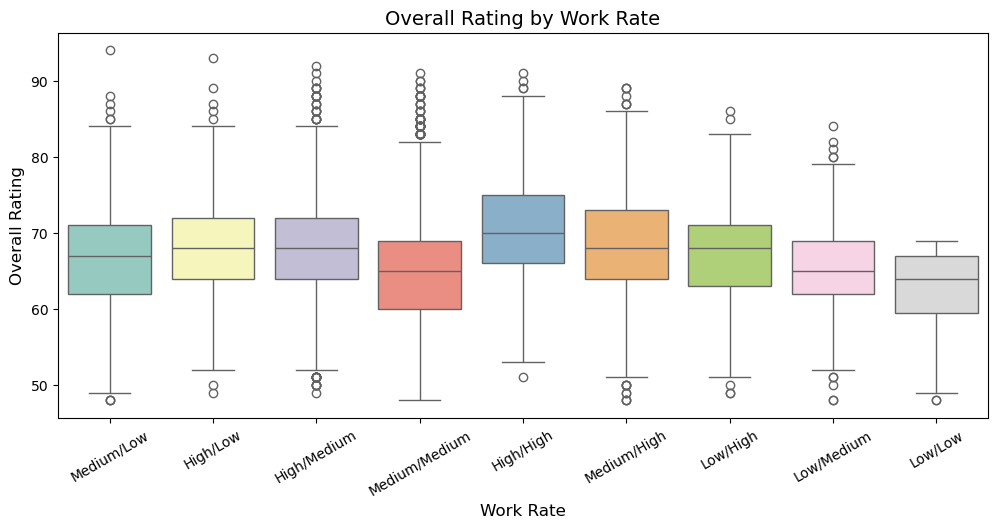

In [121]:
plt.figure(figsize=(12,5))  

sns.boxplot(
    x='work_rate',
    y='overall',
    hue='work_rate',        
    data=data,
    palette='Set3',
    legend=False            
)

plt.title("Overall Rating by Work Rate", fontsize=14)
plt.xlabel("Work Rate", fontsize=12)
plt.ylabel("Overall Rating", fontsize=12)
plt.xticks(rotation=30)    
plt.show()

- Players with higher work rates tend to have higher overall ratings.
-  It's a valid outliers, not errors.

### Age vs Overall Rating

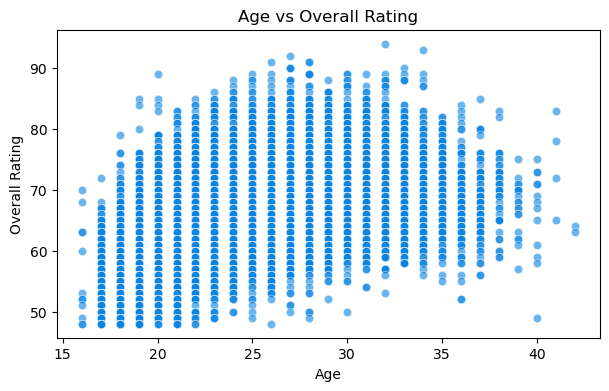

In [122]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    x='age',
    y='overall',
    data=data,
    alpha=0.6,
    color='#0984e3'
)
plt.title("Age vs Overall Rating")
plt.xlabel("Age")
plt.ylabel("Overall Rating")
plt.show()

| Age Range | Overall Rating Trend                   |
| --------- | -------------------------------------- |
| Below 20  | Lower and highly variable              |
| 20–25     | Rapid improvement                      |
| 26–29     | Peak performance                       |
| 30–34     | Gradual decline                        |
| 35+       | Noticeable decline with few exceptions |


### Skill vs Overall

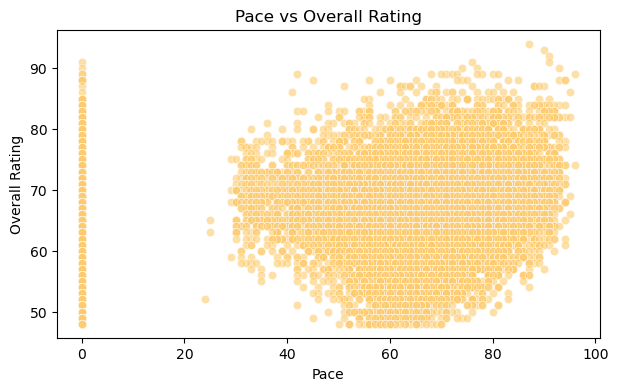

In [123]:
plt.figure(figsize=(7,4))
sns.scatterplot(
    x='pace',
    y='overall',
    data=data,
    alpha=0.6,
    color='#fdcb6e'
)
plt.title("Pace vs Overall Rating")
plt.xlabel("Pace")
plt.ylabel("Overall Rating")
plt.show()


| Pace Range        | Overall Rating Trend                     |
| ----------------- | ---------------------------------------- |
| Very Low (0–30)   | Mostly low overall ratings               |
| Moderate (30–50)  | Gradual improvement in overall           |
| High (50–75)      | Generally higher overall ratings         |
| Very High (75–95) | High overall ratings with some variation |


## Multivariate Analysis

Multivariate analysis uses more than one independent variable at the same time.

### Correlation Heatmap

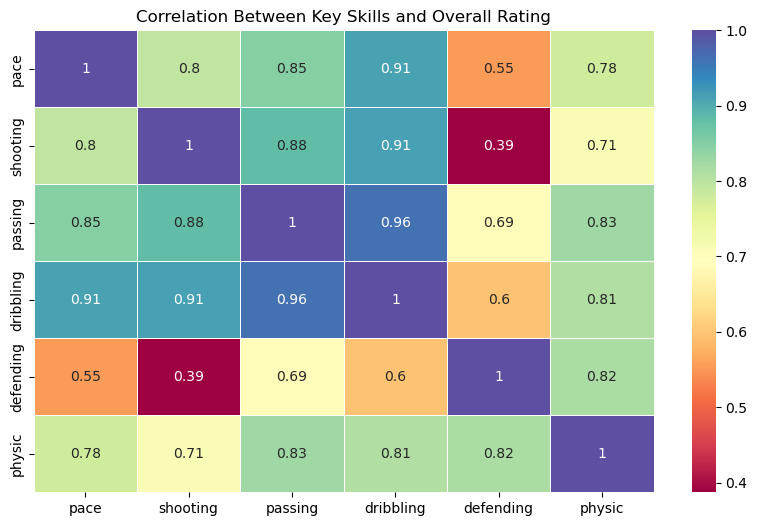

In [124]:
plt.figure(figsize=(10,6))
sns.heatmap(
    data[['pace','shooting','passing','dribbling','defending','physic']].corr(),
    annot=True,
    cmap='Spectral',
    linewidths=0.5
)
plt.title("Correlation Between Key Skills and Overall Rating")
plt.show()


| Skill Pair           | Correlation Strength | Interpretation                            |
| -------------------- | -------------------- | ----------------------------------------- |
| Passing – Dribbling  | Very Strong (0.96)   | Technical skills strongly move together   |
| Pace – Dribbling     | Strong (0.91)        | Faster players tend to dribble better     |
| Shooting – Dribbling | Strong (0.91)        | Attackers combine shooting with dribbling |
| Shooting – Passing   | Strong (0.88)        | Creative attackers excel in both          |
| Physic – Defending   | Strong (0.82)        | Physical strength supports defense        |
| Passing – Physic     | Strong (0.83)        | Balanced technical–physical players       |
| Pace – Defending     | Moderate (0.55)      | Speed helps defense but is not dominant   |
| Shooting – Defending | Weak (0.39)          | Shooting skill unrelated to defending     |


### Pairwise Relationships

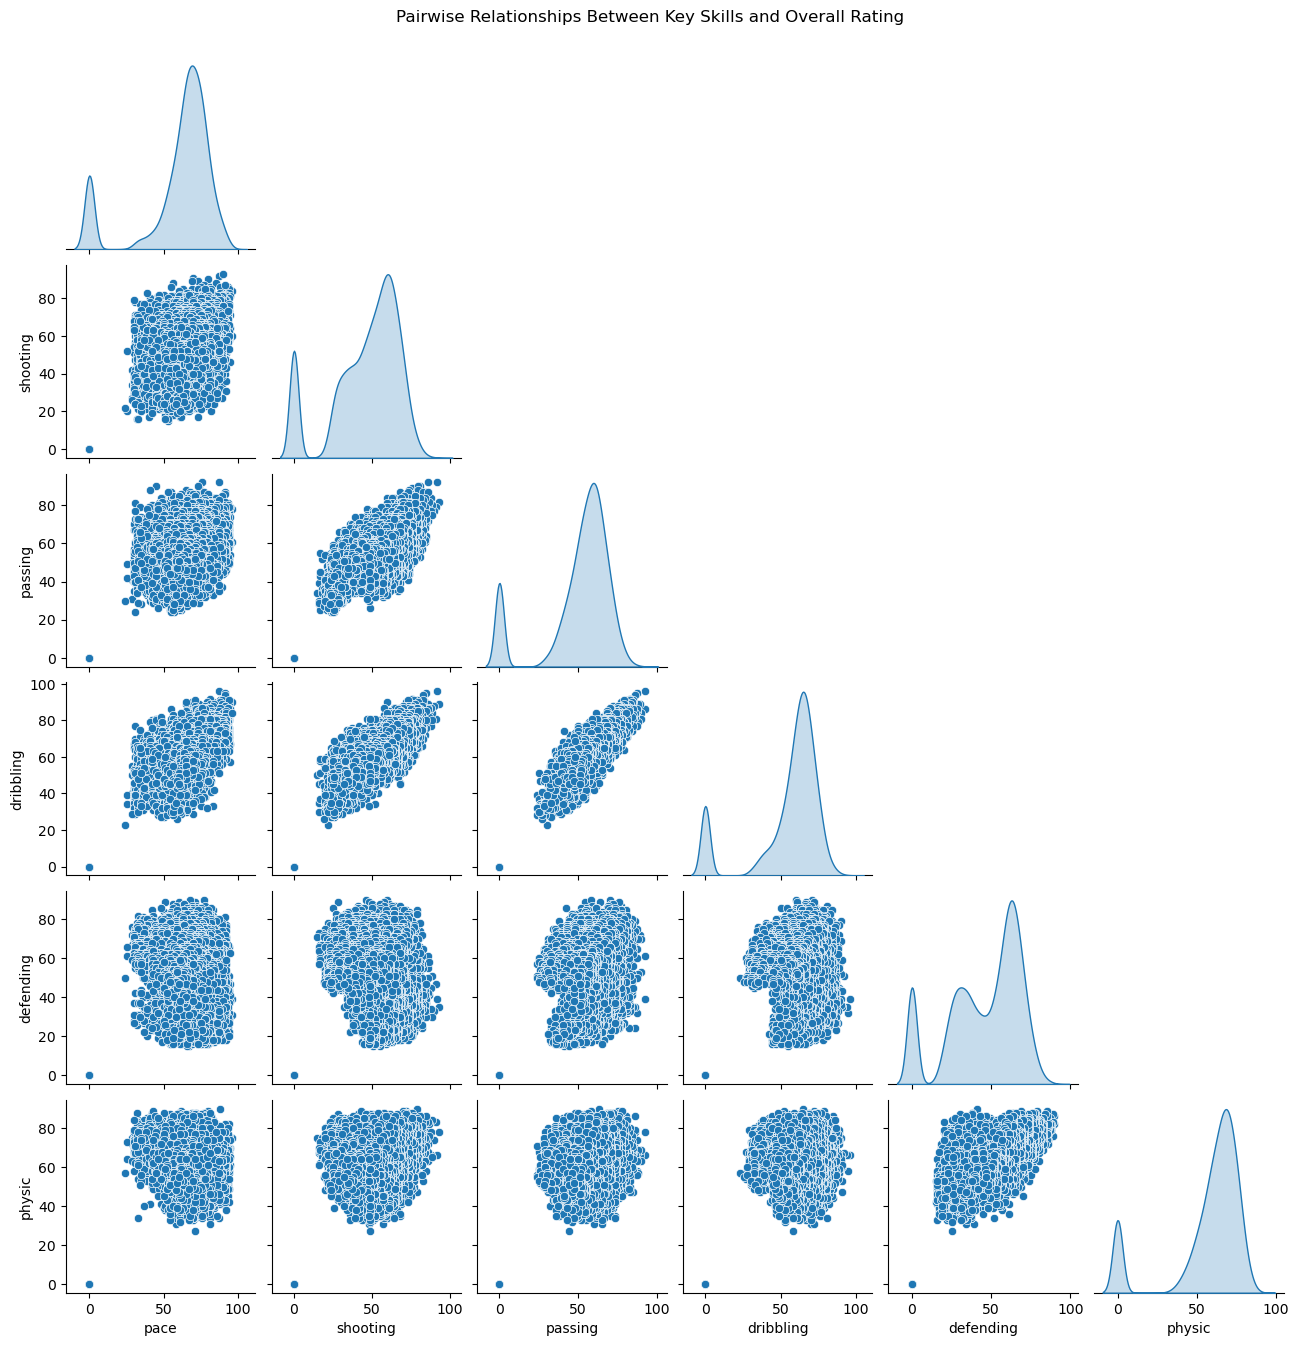

In [125]:
key_skills = [
    'pace','shooting','passing','dribbling',
    'defending','physic'
]

sns.pairplot(
    data[key_skills],
    corner=True,          
    diag_kind='kde',
    height=2.2,           
    aspect=1              
)

plt.suptitle(
    "Pairwise Relationships Between Key Skills and Overall Rating",
    y=1.02
)
plt.show()

| Feature Combination          | Relationship Observed | Interpretation                            |
| ---------------------------- | --------------------- | ----------------------------------------- |
| Pace – Shooting              | Moderate positive     | Faster players often have better shooting |
| Pace – Passing               | Moderate positive     | Speed supports attacking play             |
| Pace – Dribbling             | Strong positive       | Fast players are usually good dribblers   |
| Shooting – Passing           | Strong positive       | Attackers combine shooting with passing   |
| Passing – Dribbling          | Very strong positive  | Technical skills improve together         |
| Defending – Physic           | Strong positive       | Physical strength supports defense        |
| Defending – Attacking Skills | Weak                  | Defensive skills are independent          |
| Single Skill Alone           | Limited impact        | Balanced skill set matters more           |


#### Insight:


Based on the **exploratory analysis**, relevant skill-based features were identified and prepared for clustering analysis.

### Select features (NO overall)

In [126]:
cluster_features = [
    'pace','shooting','passing',
    'dribbling','defending','physic'
]

In [127]:
data = data[~(data[cluster_features].sum(axis=1) == 0)]

In [128]:
X = data[cluster_features]

### Scale the data

In [129]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Find optimal clusters (Elbow Method)

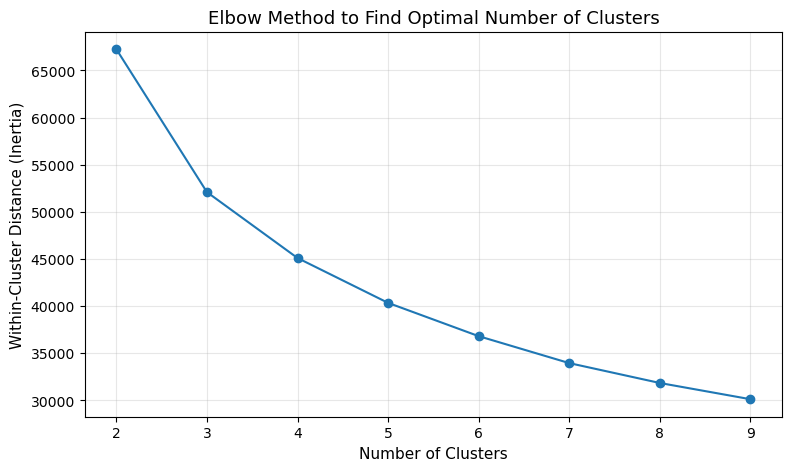

In [130]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(9,5))
plt.plot(
    k_range,
    inertia,
    marker='o',
    linestyle='-'
)
plt.xticks(k_range)
plt.xlabel("Number of Clusters", fontsize=11)
plt.ylabel("Within-Cluster Distance (Inertia)", fontsize=11)
plt.title("Elbow Method to Find Optimal Number of Clusters", fontsize=13)
plt.grid(True, alpha=0.3)
plt.show()

**Insight :**

- Very sharp drop from k = 2 → 3
- Clear improvement from k = 3 → 4
- After k = 4, the curve flattens
- From k = 5 onward, improvements are very small<br>
- This bend in the curve is called the **“elbow”**

### Apply KMeans

In [131]:
kmeans = KMeans(n_clusters=4,
                random_state=42,
                n_init=10)

data['cluster'] = kmeans.fit_predict(X_scaled)

In [133]:
data.groupby('cluster')[cluster_features].mean()

,pace,shooting,passing,dribbling,defending,physic
cluster,,,,,,
0,58.047606,33.616370,45.775334,48.750557,61.915924,67.928174
1,76.521437,67.298378,64.779838,72.521437,38.720742,63.992758
2,68.995516,54.057768,52.220522,61.346610,34.457927,54.584015
3,67.574810,53.899020,63.543185,66.139634,64.848530,70.630294


| Cluster | Key Skill Pattern                                    | Player Type                             |
| ------- | ---------------------------------------------------- | --------------------------------------- |
| **0**   | Low shooting & passing, strong defending & physic    | **Defensive Specialists**               |
| **1**   | Very high pace, shooting & dribbling, low defending  | **Attacking Players / Forwards**        |
| **2**   | Moderate pace & dribbling, weak defending & physic   | **Supporting Attackers / Wide Players** |
| **3**   | Balanced attacking & defensive skills, strong physic | **All-Rounders / Central Players**      |


In [134]:
data['cluster'].value_counts()

cluster
3    5407
2    3791
0    3592
1    3452
Name: count, dtype: int64

| Cluster | Number of Players | Interpretation               |
| ------- | ----------------- | ---------------------------- |
| 0       | 3,592             | Defensive specialists        |
| 1       | 3,452             | Attacking players            |
| 2       | 3,791             | Supporting attackers         |
| 3       | 5,407             | All-round / balanced players |

- KMeans clustering grouped players into four distinct clusters based on their core skill attributes. Each cluster represents a unique playing style, such as defensively oriented players, attack-focused players, supporting attackers, and balanced all-rounders. 
- The clusters are well-separated and contain reasonable numbers of players, indicating effective and meaningful segmentation of football player profiles.


### Hierarchical Clustering

Hierarchical clustering was applied as a supporting technique to understand player similarity and validate the clustering structure obtained from KMeans.


#### Dendrogram 
- A dendrogram is a tree-like diagram that shows how data points (players) are grouped together step by step in hierarchical clustering.

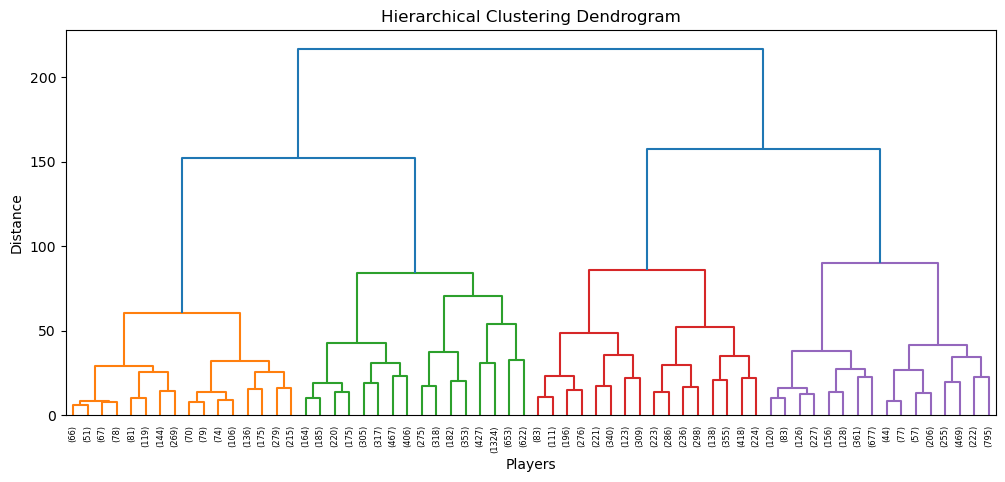

In [135]:
linked = linkage(X_scaled, method='ward') 
plt.figure(figsize=(12,5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Players")
plt.ylabel("Distance")
plt.show()
# Ward’s method combines clusters so that players inside a cluster are as similar to each other as possible.
#linkage : “How do we measure similarity between clusters?”

| Observation          | Meaning                           |
| -------------------- | --------------------------------- |
| Low-height merges    | Very similar players              |
| High vertical jumps  | Natural separation between groups |
| Cut at ~150 distance | 4 clear player groups             |
| Symmetric structure  | Balanced clusters                 |


### Agglomerative Clustering

In [136]:
hc = AgglomerativeClustering(n_clusters=4, linkage='ward')
data['hc_cluster'] = hc.fit_predict(X_scaled)

#### Compare Cluster Profiles

In [137]:
data.groupby('hc_cluster')[cluster_features].mean()

,pace,shooting,passing,dribbling,defending,physic
hc_cluster,,,,,,
0,74.640769,65.893830,68.404197,73.406945,51.267050,66.880090
1,66.403879,46.738464,57.837948,61.341467,60.875332,67.156421
2,69.682825,58.494918,52.617931,62.824342,30.779776,57.309356
3,54.215032,31.066202,41.869587,44.090095,62.136386,68.083126


| HC Cluster | Skill Pattern                                   | Player Profile                          |
| ---------- | ----------------------------------------------- | --------------------------------------- |
| **0**      | Very high pace, shooting, passing, dribbling    | **Elite Attackers / Creative Forwards** |
| **1**      | Balanced passing, defending, physic             | **Central / Box-to-Box Players**        |
| **2**      | High pace & shooting, very low defending        | **Wide Attackers / Wingers**            |
| **3**      | Low attacking skills, strong defending & physic | **Defensive Specialists**               |


In [138]:
data['hc_cluster'].value_counts()

hc_cluster
1    6393
0    4003
2    3837
3    2009
Name: count, dtype: int64

| Cluster | Players | Interpretation                      |
| ------- | ------- | ----------------------------------- |
| 0       | 4,003   | Defensive and physical players      |
| 1       | 6,393   | Balanced all-round players          |
| 2       | 3,837   | Supporting attackers / wide players |
| 3       | 2,009   | High-impact attackers               |


- Hierarchical clustering grouped players into four distinct clusters based on their skill attributes, representing different playing profiles such as defensive, attacking, and balanced players. The cluster sizes are reasonably distributed, indicating stable segmentation without extreme imbalance.
- The similarity between hierarchical clustering results and KMeans clusters further validates the choice of four clusters and confirms the robustness of the player grouping.


### Alternative Clustering Approach: DBSCAN

- KMeans = Main Result
- DBSCAN = Supporting Evidence

In [139]:
dbscan = DBSCAN(
    eps=1.2,        
    min_samples=15  
)
data['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

In [140]:
data['dbscan_cluster'].value_counts()

dbscan_cluster
 0    16228
-1       14
Name: count, dtype: int64

| DBSCAN Label | Number of Players | Meaning                     |
| ------------ | ----------------- | --------------------------- |
| 0            | 16,228            | Main dense group of players |
| -1           | 14                | Noise / Outliers            |

- DBSCAN found one large dense cluster
- Identified 14 players as outliers
- Dataset is uniformly dense (most data points have similar spacing and density, so they form one big group instead of many separate groups.)
- DBSCAN is not ideal for separating player roles here

**Insight :**

- DBSCAN was applied as an alternative clustering method to identify dense player groups and detect outliers. While DBSCAN successfully identified noise points, it did not produce well-separated clusters due to the uniform density of the dataset.
- Hierarchical clustering was used as a supporting approach and produced player groupings consistent with the KMeans results.
- KMeans, on the other hand, produced more interpretable and balanced clusters and was therefore selected as the primary clustering approach for player segmentation.


### Clustering Methods

| Algorithm        | What It Does                               | What We Observed                          | Final Use                       |
| ---------------- | ------------------------------------------ | ----------------------------------------- | ------------------------------- |
| **KMeans**       | Groups players based on skill similarity   | Formed 4 clear and balanced player groups | **Main clustering method**      |
| **Hierarchical** | Shows how players are grouped step-by-step | Produced similar groups to KMeans         | Used to validate results        |
| **DBSCAN**       | Finds dense groups and outliers            | Found one large group and a few outliers  | Used only for outlier detection |


#### Top 10 Countries Producing Most Players

In [141]:
top_countries = (
    data['nationality']
    .value_counts()
    .head(10)
    .reset_index()
)

top_countries.columns = ['Country', 'Number_of_Players']
top_countries

,Country,Number_of_Players
0,England,1497
1,Germany,1055
2,Spain,922
3,France,881
4,Argentina,796
5,Brazil,751
6,Italy,630
7,Colombia,545
8,Japan,398
9,Netherlands,364


- England produces the highest number of professional football players in the dataset, followed by Germany and Spain. 
- European countries dominate the top 10 list, highlighting the strength of their football infrastructure, domestic leagues, and youth development systems. 
- South American countries such as Argentina and Brazil also contribute significantly, reflecting their strong football culture and talent production.


#### Distribution of Overall Rating vs Age

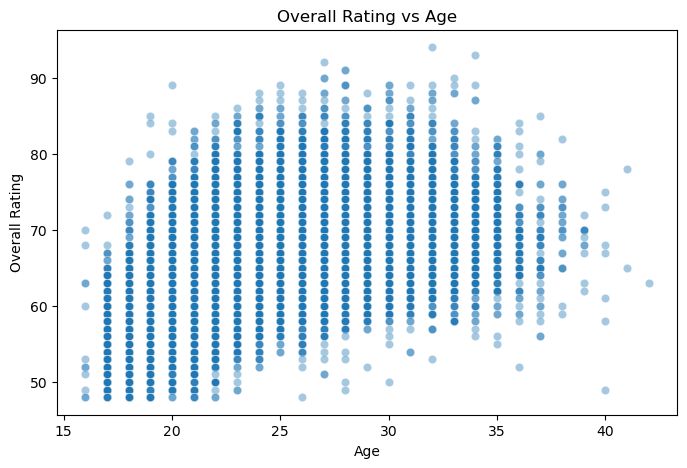

In [142]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='age',
    y='overall',
    data=data,
    alpha=0.4
)
plt.title("Overall Rating vs Age")
plt.xlabel("Age")
plt.ylabel("Overall Rating")
plt.show()

| Age Range | Trend in Overall Rating | Interpretation                          |
| --------- | ----------------------- | --------------------------------------- |
| Below 20  | Gradual increase        | Players are developing basic skills     |
| 20–25     | Rapid improvement       | Strong skill growth and experience gain |
| 26–28     | Peak performance        | Players reach maximum overall potential |
| 29–30     | Stable performance      | Improvement slows down                  |
| Above 30  | Gradual decline         | Physical ability starts reducing        |

- Player overall ratings increase with age and typically peak around 28–30 years, after which improvement slows down or declines.


### Offensive Players and Their Salaries

**We compare :**

- Strikers (ST)
- Right Wingers (RW)
- Left Wingers (LW)

In [143]:
offensive_positions = data[
    data['player_positions'].str.contains('ST|RW|LW', regex=True, na=False)
]

salary_by_position = (
    offensive_positions
    .groupby('player_positions')['wage_eur']
    .mean()
    .reset_index()
    .sort_values(by='wage_eur', ascending=False)
)

salary_by_position.head(10)

,player_positions,wage_eur
286,"RW, CF, ST",565000.000000
48,"CF, LW, ST",140000.000000
59,"CF, ST, LW",126000.000000
44,"CF, LM, LW",89000.000000
53,"CF, RW, RM",79000.000000
280,"RW, CAM, CM",78666.666667
52,"CF, RW, LW",78000.000000
154,"LW, CF",72000.000000
14,"CAM, RM, RW",64000.000000
138,"LM, RW, LW",52333.333333


### Offensive Player Position Categorization


In [144]:
def clean_position(pos):
    if 'ST' in pos:
        return 'ST'
    elif 'LW' in pos:
        return 'LW'
    elif 'RW' in pos:
        return 'RW'
    else:
        return np.nan

data['offensive_role'] = data['player_positions'].apply(clean_position)
offensive_data = data[data['offensive_role'].notna()]

### Average Wage of Offensive Players by Position

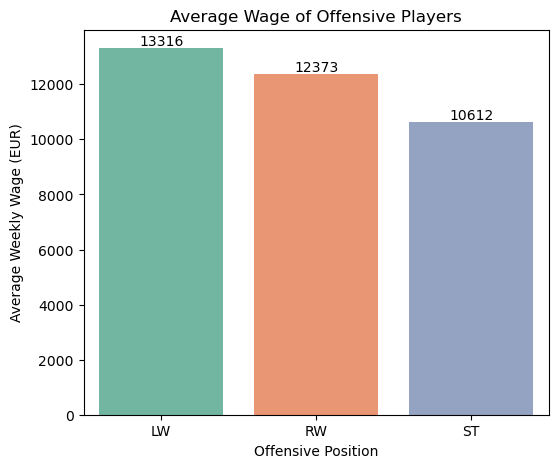

In [145]:
plt.figure(figsize=(6,5))
ax = sns.barplot(
    data=mean_wage,
    x='offensive_role',
    y='wage_eur',
    hue='offensive_role',   # ✅ added
    palette='Set2',
    legend=False            # ✅ removes extra legend
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.title("Average Wage of Offensive Players")
plt.xlabel("Offensive Position")
plt.ylabel("Average Weekly Wage (EUR)")
plt.show()

**Insight:**  

**Left-wingers (LW) and right-wingers (RW) show slightly higher average wages than strikers (ST), likely due to the influence of multi-position players and high-earning wide attackers.**

